# Assignment 7

# Customer Segmentation using K-Means Clustering and Principal Component Analysis (PCA)

**Name:** Khushie Brahma

**Assignment Number:** Assignment 7

## Objective

The objective of this assignment is to perform customer segmentation using the K-Means Clustering algorithm and visualize the customer groups using Principal Component Analysis (PCA). This helps identify customer segments based on their annual income and spending behavior for targeted marketing.

## 1: Import Required Libraries

In [51]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

## 2: Load Dataset

In [52]:
df = pd.read_csv("../data/Mall_Customers.csv")

## 3: Display First Five Records

In [53]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 4: Data Understanding

In [54]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (200, 5)


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [56]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### Numerical Features

- Age
- Annual Income (k$)
- Spending Score (1-100)

### Categorical Features

- Gender

### Identifier Column

- CustomerID

In [57]:
df.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

### Observation

The Mall Customer Segmentation dataset was successfully loaded into a Pandas DataFrame. It contains customer information such as gender, age, annual income, and spending score. The dataset includes three numerical features and one categorical feature, while `CustomerID` serves as an identifier. The dataset information and summary statistics provide a clear understanding of the data before preprocessing.

## 5: Data Preprocessing

### Check for Missing Values

In [58]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### Remove Unnecessary Columns

In [59]:
df = df.drop("CustomerID", axis=1)

In [60]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


### Encode the Categorical Variable

In [61]:
label_encoder = LabelEncoder()

df["Gender"] = label_encoder.fit_transform(df["Gender"])

In [62]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


### Standardize Numerical Features

In [63]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

In [64]:
scaled_df = pd.DataFrame(
    scaled_data,
    columns=df.columns
)

scaled_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1.128152,-1.424569,-1.738999,-0.434801
1,1.128152,-1.281035,-1.738999,1.195704
2,-0.886405,-1.352802,-1.700830,-1.715913
3,-0.886405,-1.137502,-1.700830,1.040418
4,-0.886405,-0.563369,-1.662660,-0.395980


In [65]:
print("Shape of Scaled Dataset:", scaled_df.shape)

Shape of Scaled Dataset: (200, 4)


### Observation

The dataset was successfully preprocessed by checking for missing values, removing the unnecessary `CustomerID` column, encoding the categorical `Gender` feature into numerical values, and standardizing all features using `StandardScaler`. Feature scaling is an essential preprocessing step for K-Means clustering because it ensures that all variables contribute equally to distance calculations, preventing features with larger numerical ranges from dominating the clustering process.

## 6: Model Development

### Determine the Optimal Number of Clusters using the Elbow Method

In [66]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

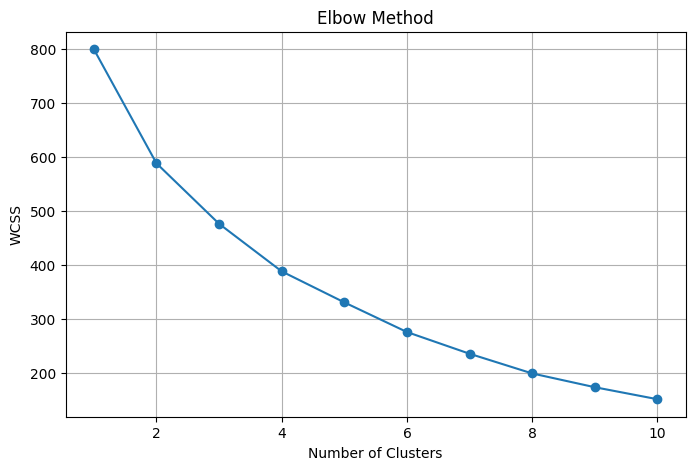

In [67]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.grid(True)

plt.show()

### Train the K-Means Clustering Model

In [68]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_df)

### Assign Cluster Labels

In [69]:
df["Cluster"] = clusters

In [70]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,3
1,1,21,15,81,3
2,0,20,16,6,3
3,0,23,16,77,3
4,0,31,17,40,3


In [71]:
df["Cluster"].value_counts().sort_index()

Cluster
0    39
1    29
2    43
3    54
4    35
Name: count, dtype: int64

### Apply Principal Component Analysis (PCA)

In [72]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_df)

In [73]:
pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = clusters

In [74]:
pca_df.head()

,PC1,PC2,Cluster
0,-0.406383,-0.520714,3
1,-1.427673,-0.367310,3
2,0.050761,-1.894068,3
3,-1.694513,-1.631908,3
4,-0.313108,-1.810483,3


### Observation

The Elbow Method was used to identify the optimal number of customer clusters, and **K = 5** was selected based on the elbow point. A K-Means clustering model was trained using the standardized dataset, and each customer was assigned to a cluster. Principal Component Analysis (PCA) was then applied to reduce the dataset to two principal components, making it easier to visualize the customer segments in a two-dimensional space.

## 7: Visualization and Evaluation

### Elbow Curve

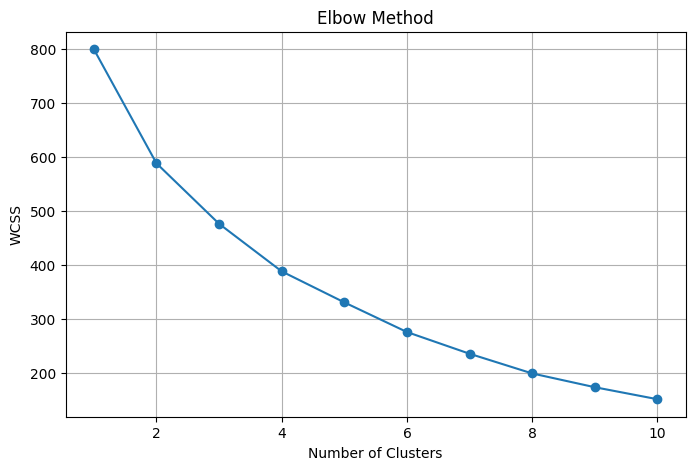

In [75]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.grid(True)

plt.savefig(
    "../images/elbow_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Customer Cluster Scatter Plot

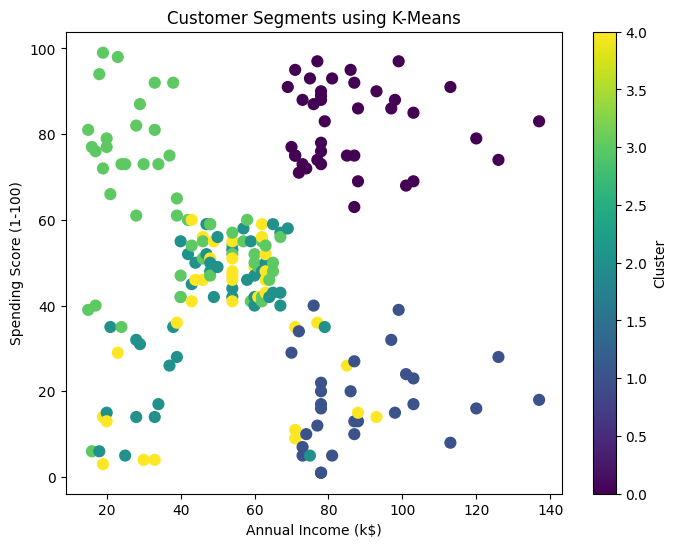

In [76]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=60
)

plt.title("Customer Segments using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.colorbar(label="Cluster")

plt.savefig(
    "../images/customer_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### PCA Visualization

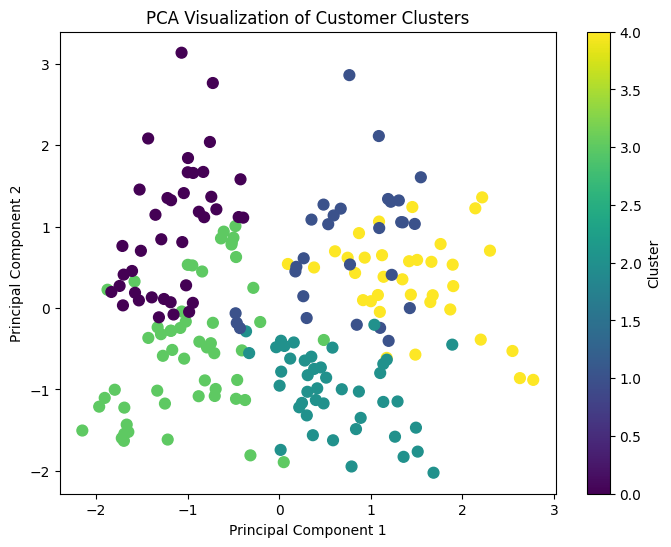

In [77]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap="viridis",
    s=60
)

plt.title("PCA Visualization of Customer Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.savefig(
    "../images/pca_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observations

1. The Elbow Method indicates that **5** is the optimal number of customer clusters, as the reduction in WCSS becomes less significant after this point.

2. The scatter plot shows that customers are grouped into distinct segments based on their annual income and spending score, making it easier to identify different purchasing behaviors.

3. Principal Component Analysis (PCA) successfully reduced the dataset to two dimensions while preserving most of the important information, allowing the customer clusters to be visualized clearly.

4. The identified customer groups can help businesses design targeted marketing campaigns and personalized promotional strategies for different customer segments.

## 8: Conclusion

The objective of this assignment was to segment customers using the K-Means Clustering algorithm and visualize the clusters using Principal Component Analysis (PCA). The Elbow Method identified **5** as the optimal number of clusters, allowing customers to be grouped based on their purchasing behavior and annual income. PCA successfully reduced the dataset to two principal components, making the customer segments easy to visualize and interpret. Customer segmentation helps businesses develop targeted marketing campaigns, improve customer satisfaction, and optimize promotional strategies for different customer groups. One limitation of K-Means clustering is that the number of clusters must be chosen in advance and it may not perform well on clusters with irregular shapes. A major advantage of PCA is its ability to reduce data dimensionality while preserving most of the important information for visualization and analysis.